In [3]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.3)
  from scipy.stats import gaussian_kde


In [4]:
from torch_geometric.datasets import Planetoid

In [5]:
dataset=Planetoid('root/Planetoid',name='Cora')

In [6]:
data=dataset[0]

In [7]:
print("number of paper {nodes}",data.num_nodes)
print("number of citations {edges}",data.num_edges)
print("number of features per paper",data.num_features)
print("number of topics",{dataset.num_classes})
print("tranning papers",{data.train_mask.sum()})
print("testing papers",{data.test_mask.sum()})
print("valadiation papers",{data.val_mask.sum()})

number of paper {nodes} 2708
number of citations {edges} 10556
number of features per paper 1433
number of topics {7}
tranning papers {tensor(140)}
testing papers {tensor(1000)}
valadiation papers {tensor(500)}


In [8]:
topic_counts=pd.Series(data.y.numpy()).value_counts().sort_index()

<Axes: xlabel='None', ylabel='count'>

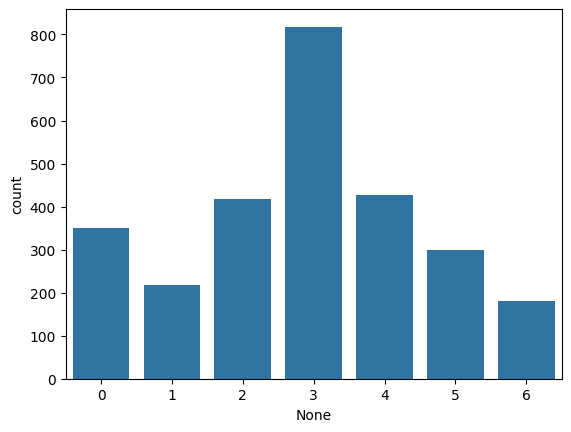

In [9]:
sns.barplot(x=topic_counts.index,y=topic_counts)

In [10]:
#creating base line model
X_binary=data.x.numpy()
y=data.y.numpy()
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.ensemble import RandomForestClassifier
tfidf=TfidfTransformer()
X_tfidf=tfidf.fit_transform(X_binary).toarray()
X_baseline=X_tfidf#it comes from feature
train_idx=data.train_mask.numpy()#traning research papers
test_idx=data.test_mask.numpy()
val_idx=data.val_mask.numpy()
X_train ,y_train = X_baseline[train_idx], y[train_idx]
X_test ,y_test = X_baseline[test_idx],y[test_idx]
rf=RandomForestClassifier(n_estimators=100,max_features='sqrt',class_weight='balanced',random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)

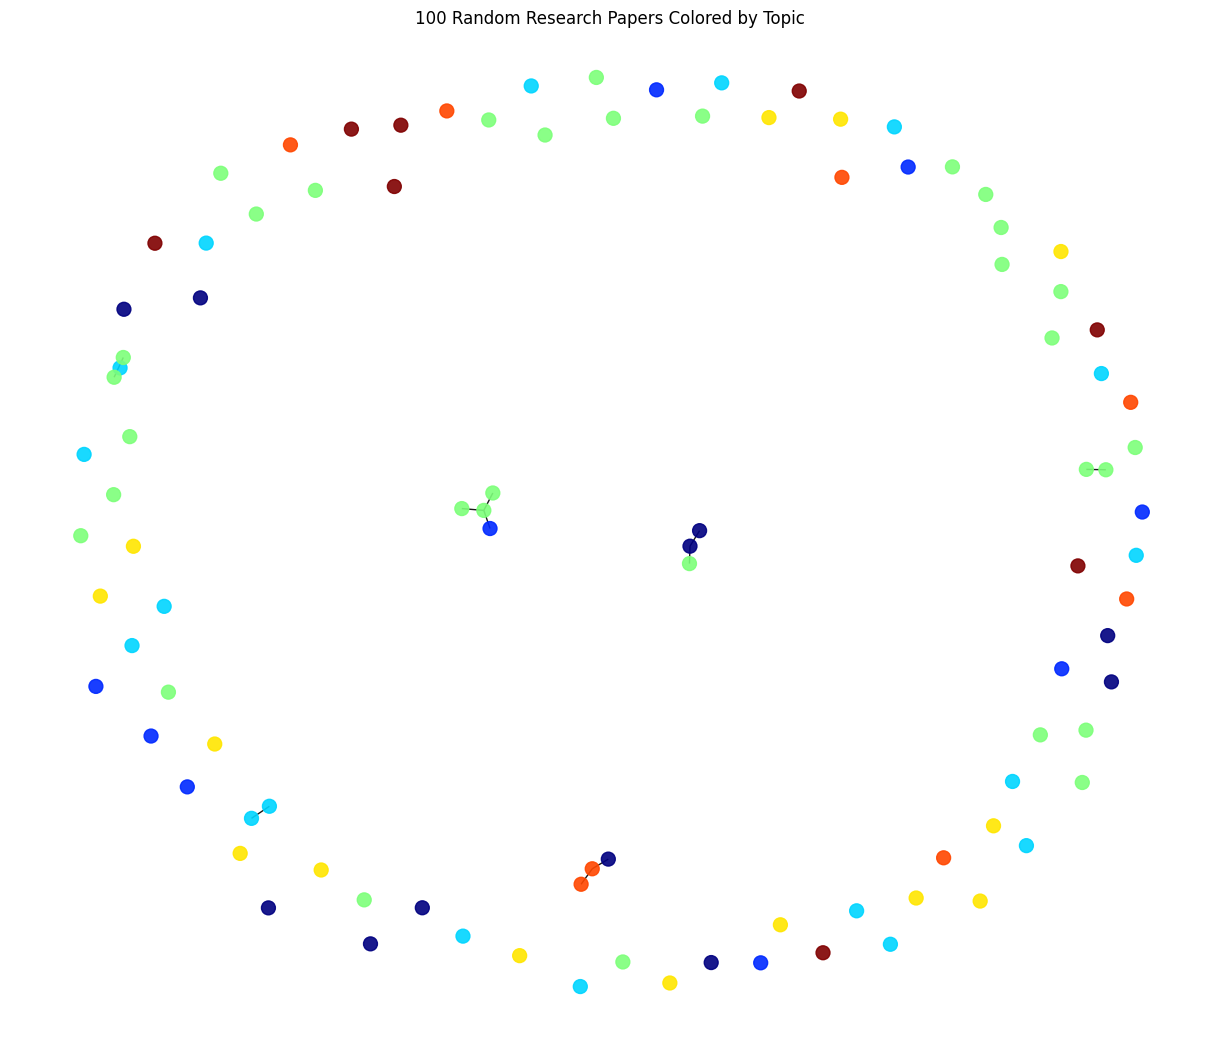

In [11]:
from torch_geometric.utils import to_networkx

import networkx as nx
import random
import matplotlib.pyplot as plt


SEED = 12345

# Convert the PyTorch Geometric data object to a NetworkX graph
G = to_networkx(data, to_undirected=True)

# Select 100 random nodes
random.seed(SEED)
sampled_nodes = random.sample(list(G.nodes()), 100)

# Create a graph using only those nodes
sample_graph = G.subgraph(sampled_nodes)
# Get the topic of each node
node_colors = [
    data.y[node].item()
    for node in sample_graph.nodes()
]

# Create positions for the nodes
pos = nx.spring_layout(sample_graph, seed=SEED)

# Draw the graph
plt.figure(figsize=(12, 10))

nx.draw(
    sample_graph,
    pos,
    node_color=node_colors,
    cmap=plt.cm.jet,
    node_size=100,
    alpha=0.9,
    with_labels=False
)
plt.title("100 Random Research Papers Colored by Topic")
plt.axis("off")
plt.show()

In [12]:
#evaluation
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix
rf_accuracy=accuracy_score(y_test,rf_pred)
rf_f1=f1_score(y_test,rf_pred,average='macro')
print(f'Accuracy:{accuracy_score(y_test,rf_pred):.4f}')
print(f'f1_Macro:{f1_score(y_test,rf_pred,average='macro'):.4f}')

Accuracy:0.5800
f1_Macro:0.5818


<Axes: >

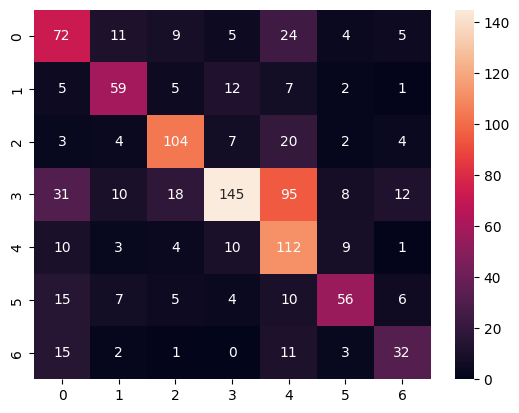

In [13]:
sns.heatmap(confusion_matrix(y_test,rf_pred),annot=True,fmt='d')

In [14]:
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import GCNConv
class SimpleGCN(nn.Module):
    def __init__(self,input_dim,hidden_dim,output_dim,dropout=0.5):
        super().__init__()
        self.conv1=GCNConv(input_dim,hidden_dim)
        self.conv2=GCNConv(hidden_dim,output_dim)
        self.dropout=dropout
    def forward(self,x,edge_index):
        x=self.conv1(x,edge_index)
        x=F.relu(x)
        x=F.dropout(x,p=self.dropout,training=self.training)
        x=self.conv2(x,edge_index)
        return x
model=SimpleGCN(
    input_dim=data.num_features,
    hidden_dim=32,
    output_dim=dataset.num_classes,
) 
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)   
print(model)


        
        




    

SimpleGCN(
  (conv1): GCNConv(1433, 32)
  (conv2): GCNConv(32, 7)
)


In [15]:
X_binary=data.x.numpy()
y=data.y.numpy()

In [16]:
# tfidf reweight the supplies word indicator
from sklearn.feature_extraction.text import TfidfTransformer
tfidf=TfidfTransformer()
X_tfidf=tfidf.fit_transform(X_binary).toarray()
X_tfidf



array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(2708, 1433), dtype=float32)

In [17]:

def train_one_epoch():
    model.train()#model tain ker ne k baad gradient calculate hota hai tho by default zero nahi hota gradient tho zero kerna padta hai
    optimizer.zero_grad()
    logits=model(data.x,data.edge_index)
    loss=F.cross_entropy(logits[data.train_mask],data.y[data.train_mask])  
    loss.backward()
    optimizer.step()
    return loss.item()
@torch.no_grad()
def evaluate(mask):
    model.eval()
    logits = model(data.x, data.edge_index) # Pass full edge_index to the model
    predictions = logits.argmax(dim=1)
    accuracy = (predictions[mask] == data.y[mask]).float().mean().item() # Corrected accuracy calculation
    macro_f1 = f1_score(
        data.y[mask].numpy(),
        predictions[mask].numpy(),
        average="macro"
    )
    return accuracy, macro_f1, predictions


In [18]:
losses, train_accuracies, val_accuracies = [], [], []
best_val_accuracy = 0.0
best_state = None

epoch_without_improvement = 0
patience = 20 #Stop i no improvement for this many epochs

for epoch in range(1, 201):
    loss = train_one_epoch()
    train_accuracy,_,_ = evaluate(data.train_mask)#only give the traning accuracy
    val_accuracy,_,_ = evaluate(data.val_mask)#only give the val accuracy

    losses.append(loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy) #0.70

    if val_accuracy > best_val_accuracy: #0.56 > 0.70
       best_val_accuracy = val_accuracy
       best_state = model.state_dict()
       epoch_without_improvement = 0

    else:
     epoch_without_improvement += 1

    if epoch_without_improvement >= patience:
      print(f"Early stopping at epoch {epoch}")
      break

    if epoch == 1 or epoch % 10 == 0:
      
      print(f"Epoch: {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f} |Best Val Acc: {best_val_accuracy:.4f}")


model.load_state_dict(best_state)
gcn_accuracy, gcn_f1, gcn_pred = evaluate(data.test_mask)

print(f"\nGCN test accuracy: {gcn_accuracy:.3f}")
print(f"GCN test macro-F1: {gcn_f1:.3f}")


Epoch: 001 | Loss: 1.9362 | Train Acc: 0.7714 | Val Acc: 0.4340 |Best Val Acc: 0.4340
Epoch: 010 | Loss: 0.4076 | Train Acc: 0.9857 | Val Acc: 0.7880 |Best Val Acc: 0.7900
Epoch: 020 | Loss: 0.0512 | Train Acc: 1.0000 | Val Acc: 0.7680 |Best Val Acc: 0.7960
Epoch: 030 | Loss: 0.0155 | Train Acc: 1.0000 | Val Acc: 0.7620 |Best Val Acc: 0.7960
Early stopping at epoch 34

GCN test accuracy: 0.787
GCN test macro-F1: 0.782


<Axes: >

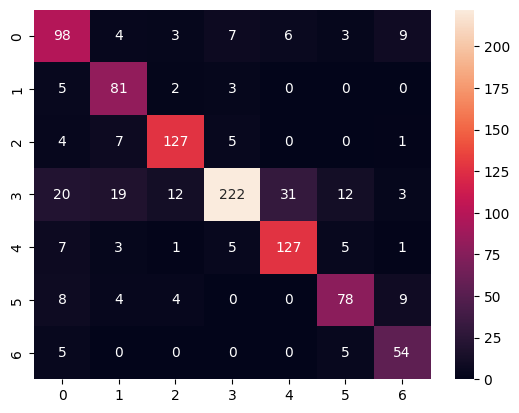

In [19]:
#Confusion MArix for GCN model.
sns.heatmap(
    confusion_matrix(data.y[data.test_mask].numpy(), gcn_pred[data.test_mask].numpy()),
    annot=True,
    fmt="d"
)

In [20]:
results = pd.DataFrame({
    "Model": ["Random Forest", "GCN"],
    "Accuracy": [rf_accuracy, gcn_accuracy],
    "Macro-F1": [rf_f1, gcn_f1]
})

In [21]:
results

,Model,Accuracy,Macro-F1
0,Random Forest,0.580,0.581814
1,GCN,0.787,0.782254


In [22]:
import torch
%pip install onnxscript
#set the model to evaluation mode
model.eval()
#crear dummy input for the ONNX report
#the input x have sahpe [num_nodes,num_features]
#the input edge-index has shape[2,edge_index]
x_dummy = data.x
edge_index_dummy = data.edge_index

onnx_file_path = "simple_gcn_cora.onnx"
torch.onnx.export(
    model,                                            #1. Trained Model.
    (x_dummy, edge_index_dummy),                      #2. Model input.
    onnx_file_path,                                   #3. Where to save the ONNX model.
    export_params = True,                             #4. Store the trained parameter weights inside the model file.
    opset_version=18,                                 #5. Changed opset_version to 18 to avoid version conversion issues.
    do_constant_folding=True,                         #6.Whether to execute constant folding for optimation
    input_names=['node_features', 'edge_indices'],    #7. input names
    output_names=['logits'],                          #8. Output names
    dynamic_axes={
        'node_features': {0: 'num_nodes'},            #9.Variable length for num_nodes
        'edge_indices': {1: 'num_edges'}              #10.Variable length for num_edges
    }
)

print(f"Model exported to {onnx_file_path}")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Model exported to simple_gcn_cora.onnx


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\onnx\symbolic_opset9.py:5333: UserWarning: Exporting aten::index operator with indices of type Byte. Only 1-D indices are supported. In any other case, this will produce an incorrect ONNX graph.
  warnings.warn(
